Cell 1 — Train three physics-informed models

In [1]:
%%writefile /kaggle/working/heat_solver.py
import numpy as np
from boundary_conditions import apply_dirichlet_zero


def make_grid(N, L=1.0):
    """
    Create a uniform spatial grid on [0, L] x [0, L].

    Parameters
    ----------
    N : int
        Number of grid points along each axis.
    L : float
        Physical size of the domain (default 1.0).

    Returns
    -------
    x : np.ndarray, shape (N,)
    y : np.ndarray, shape (N,)
    dx : float
        Grid spacing.
    """
    x  = np.linspace(0, L, N)
    y  = np.linspace(0, L, N)
    dx = L / (N - 1)
    return x, y, dx


def compute_stable_dt(dx, alpha, safety=0.9):
    """
    Compute the maximum stable time step for the explicit
    finite-difference scheme in 2D.

    Stability condition: r = alpha * dt / dx^2 <= 1/4
    => dt_max = dx^2 / (4 * alpha)

    A safety factor < 1.0 keeps you comfortably below the limit.

    Parameters
    ----------
    dx    : float  Grid spacing.
    alpha : float  Thermal diffusivity.
    safety: float  Safety factor (default 0.9, so r = 0.225).

    Returns
    -------
    dt : float   Safe time step.
    r  : float   Fourier number (should be <= 0.25).
    """
    dt = safety * dx**2 / (4.0 * alpha)
    r  = alpha * dt / dx**2
    return dt, r


def gaussian_hotspot(x, y, cx=0.5, cy=0.5, sigma=0.1, amplitude=1.0):
    """
    Create a 2D Gaussian temperature distribution (a single hot blob).

    T0(x, y) = amplitude * exp(-((x-cx)^2 + (y-cy)^2) / (2*sigma^2))

    Parameters
    ----------
    x, y      : np.ndarray, shape (N,)  Grid coordinate vectors.
    cx, cy    : float  Center of the blob.
    sigma     : float  Width of the blob.
    amplitude : float  Peak temperature.

    Returns
    -------
    T0 : np.ndarray, shape (N, N)  Initial temperature field.
    """
    # meshgrid turns 1D coordinate vectors into 2D coordinate arrays
    X, Y = np.meshgrid(x, y)
    T0   = amplitude * np.exp(-((X - cx)**2 + (Y - cy)**2) / (2 * sigma**2))
    return T0


def step(T, r):
    """
    Advance the temperature field by one time step using the
    explicit finite-difference scheme.

    Update rule (interior points only):
    T_new[i,j] = T[i,j] + r * (T[i+1,j] + T[i-1,j]
                                + T[i,j+1] + T[i,j-1]
                                - 4*T[i,j])

    Boundary conditions (Dirichlet zero) are enforced after the update.

    Parameters
    ----------
    T : np.ndarray, shape (N, N)  Current temperature field.
    r : float                     Fourier number (alpha*dt/dx^2).

    Returns
    -------
    T_new : np.ndarray, shape (N, N)  Temperature field at next time step.
    """
    # allocate new array — never update T in place during the step,
    # because you need the OLD values of all neighbors simultaneously
    T_new = T.copy()

    # vectorized update of all interior points in one line
    T_new[1:-1, 1:-1] = (
        T[1:-1, 1:-1]
        + r * (
            T[2:,   1:-1]   # T[i+1, j]
          + T[:-2,  1:-1]   # T[i-1, j]
          + T[1:-1, 2:]     # T[i, j+1]
          + T[1:-1, :-2]    # T[i, j-1]
          - 4 * T[1:-1, 1:-1]
        )
    )

    # re-apply boundary conditions (Dirichlet zero)
    T_new = apply_dirichlet_zero(T_new)
    return T_new


def run_simulation(T0, alpha, dx, n_steps, save_every=1):
    """
    Run the full heat diffusion simulation from initial condition T0.

    Parameters
    ----------
    T0         : np.ndarray, shape (N, N)  Initial temperature field.
    alpha      : float   Thermal diffusivity.
    dx         : float   Grid spacing.
    n_steps    : int     Number of time steps to run.
    save_every : int     Save the field every this many steps.

    Returns
    -------
    snapshots : np.ndarray, shape (n_saved, N, N)
        Temperature fields at recorded time steps.
    times     : np.ndarray, shape (n_saved,)
        Physical time corresponding to each snapshot.
    dt        : float
        Time step used (derived from stability condition).
    r         : float
        Fourier number used.
    """
    dt, r = compute_stable_dt(dx, alpha)

    print(f"Grid spacing     dx = {dx:.6f}")
    print(f"Time step        dt = {dt:.6f}")
    print(f"Fourier number    r = {r:.4f}  (must be <= 0.25)")
    print(f"Total sim time      = {n_steps * dt:.4f}")

    assert r <= 0.25, f"Unstable! r={r:.4f} exceeds 0.25. Reduce dt or increase dx."

    T         = T0.copy()
    snapshots = []
    times     = []

    for n in range(n_steps + 1):
        if n % save_every == 0:
            snapshots.append(T.copy())
            times.append(n * dt)

        if n < n_steps:
            T = step(T, r)

    return np.array(snapshots), np.array(times), dt, r

Writing /kaggle/working/heat_solver.py


In [2]:
%%writefile /kaggle/working/boundary_conditions.py
import numpy as np


def apply_dirichlet_zero(T):
    """
    Apply homogeneous Dirichlet boundary conditions.
    Sets all four edges of the 2D temperature field to zero.

    Parameters
    ----------
    T : np.ndarray, shape (N, N)
        Temperature field (modified in place).

    Returns
    -------
    T : np.ndarray
        Temperature field with edges set to zero.
    """
    T[0, :]  = 0.0   # top edge
    T[-1, :] = 0.0   # bottom edge
    T[:, 0]  = 0.0   # left edge
    T[:, -1] = 0.0   # right edge
    return T


def apply_neumann_zero(T):
    """
    Apply homogeneous Neumann boundary conditions (zero flux).
    Copies the adjacent interior value to each boundary cell,
    which enforces dT/dn = 0 at every edge.

    Parameters
    ----------
    T : np.ndarray, shape (N, N)
        Temperature field (modified in place).

    Returns
    -------
    T : np.ndarray
        Temperature field with zero-flux edges.
    """
    T[0, :]  = T[1, :]    # top edge mirrors row below it
    T[-1, :] = T[-2, :]   # bottom edge mirrors row above it
    T[:, 0]  = T[:, 1]    # left edge mirrors column to its right
    T[:, -1] = T[:, -2]   # right edge mirrors column to its left
    return T

Writing /kaggle/working/boundary_conditions.py


In [3]:
%%writefile /kaggle/working/cnn.py
import torch
import torch.nn as nn


class ConvBlock(nn.Module):
    """
    A single building block: Conv2d → BatchNorm → ReLU.

    This pattern is standard in modern CNNs. BatchNorm stabilizes
    training by normalizing activations within each batch.
    ReLU introduces non-linearity — without it, stacking linear
    convolutions would still be a single linear operation.

    Parameters
    ----------
    in_channels  : int  Number of input feature maps.
    out_channels : int  Number of output feature maps (filters).
    kernel_size  : int  Filter size (default 3).
    """

    def __init__(self, in_channels, out_channels, kernel_size=3):
        super().__init__()
        padding = kernel_size // 2   # keeps spatial size unchanged

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels,
                      kernel_size=kernel_size,
                      padding=padding,
                      bias=False),       # bias=False because BatchNorm has its own bias
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class HeatSurrogateCNN(nn.Module):
    """
    Plain CNN surrogate for single-step 2D heat diffusion prediction.

    Architecture:
        Input  (1, 64, 64)
        → ConvBlock(1  → 32)
        → ConvBlock(32 → 64)
        → ConvBlock(64 → 64)
        → ConvBlock(64 → 32)
        → Conv2d(32 → 1)       final layer, no activation
        Output (1, 64, 64)

    The final layer has NO activation function because temperature
    is a continuous unbounded value — we don't want to artificially
    clip predictions to [0,1]. The network should learn to predict
    the right range from data.

    Parameters
    ----------
    n_filters : int  Base number of filters (default 32).
                     Doubling this approximately 4x the parameter count.
    """

    def __init__(self, n_filters=32):
        super().__init__()

        self.encoder = nn.Sequential(
            ConvBlock(1,            n_filters),       # (1,64,64)  → (32,64,64)
            ConvBlock(n_filters,    n_filters * 2),   # (32,64,64) → (64,64,64)
            ConvBlock(n_filters*2,  n_filters * 2),   # (64,64,64) → (64,64,64)
            ConvBlock(n_filters*2,  n_filters),       # (64,64,64) → (32,64,64)
        )

        # final projection back to 1 channel — the predicted temperature field
        self.output_layer = nn.Conv2d(
            n_filters, 1,
            kernel_size=1,    # 1x1 conv — purely a channel mixer, no spatial mixing
            bias=True
        )

    def forward(self, x):
        """
        Parameters
        ----------
        x : torch.Tensor, shape (batch, 1, H, W)

        Returns
        -------
        torch.Tensor, shape (batch, 1, H, W)
        """
        features = self.encoder(x)
        out      = self.output_layer(features)
        return out

    def count_parameters(self):
        """Return total number of trainable parameters."""
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

Writing /kaggle/working/cnn.py


In [4]:
%%writefile /kaggle/working/train_physics_informed.py

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import json
import time
from pathlib import Path
import sys

sys.path.append(str(Path(__file__).resolve().parents[1] / "models"))
sys.path.append(str(Path(__file__).resolve().parents[1] / "data"))

from cnn import HeatSurrogateCNN
from physics_informed import PhysicsInformedLoss
from dataset import load_dataset


def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True


def train_physics_informed(
    dataset_path   = "../../data/heat_dataset.npz",
    save_dir       = "../../results",
    lambda_energy  = 1.0,
    lambda_bc      = 1.0,
    lambda_pde     = 0.0,
    n_filters      = 32,
    batch_size     = 32,
    n_epochs       = 100,
    lr             = 1e-3,
    patience       = 15,
    seed           = 42,
    run_name       = "pi_cnn",
):
    """
    Train a physics-informed CNN surrogate.

    Same architecture as baseline CNN but with physics loss terms
    added to the standard MSE data loss.
    """
    set_seed(seed)

    save_dir = Path(save_dir) / run_name
    save_dir.mkdir(parents=True, exist_ok=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Device      : {device}")
    print(f"Run name    : {run_name}")
    print(f"λ_energy    : {lambda_energy}")
    print(f"λ_bc        : {lambda_bc}")
    print(f"λ_pde       : {lambda_pde}")

    # load dataset and metadata
    train_ds, val_ds, _, metadata = load_dataset(dataset_path)

    dx = float(metadata["dx"])
    dt = float(metadata["dt"])

    train_loader = DataLoader(train_ds, batch_size=batch_size,
                               shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size*2,
                               shuffle=False, num_workers=0)

    model = HeatSurrogateCNN(n_filters=n_filters).to(device)
    print(f"Parameters  : {model.count_parameters():,}")

    # physics-informed loss
    loss_fn = PhysicsInformedLoss(
        lambda_energy = lambda_energy,
        lambda_bc     = lambda_bc,
        lambda_pde    = lambda_pde,
        alpha         = float(metadata["alpha"]),
        dx            = dx,
        dt            = dt,
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=7
    )

    # tracking
    history = {k: [] for k in
               ["train_total", "train_data", "train_energy",
                "train_bc", "val_data", "val_total"]}

    best_val_data_loss = float("inf")
    epochs_no_improve  = 0
    best_epoch         = 0
    t_start            = time.time()

    print(f"\n{'Epoch':>6} {'TrainTotal':>12} {'TrainData':>12} "
          f"{'Energy':>10} {'BC':>10} {'ValData':>10}")
    print("-" * 65)

    for epoch in range(1, n_epochs + 1):

        # ── training ─────────────────────────────────
        model.train()
        epoch_losses = {k: 0.0 for k in
                        ["total", "data", "energy", "bc"]}

        for inputs, targets in train_loader:
            inputs  = inputs.to(device)
            targets = targets.to(device)

            predictions = model(inputs)

            # physics-informed loss needs inputs for energy/BC/PDE terms
            total_loss, loss_dict = loss_fn(predictions, targets, inputs)

            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()

            bs = inputs.size(0)
            for k in epoch_losses:
                epoch_losses[k] += loss_dict[k] * bs

        n_train = len(train_loader.dataset)
        for k in epoch_losses:
            epoch_losses[k] /= n_train

        # ── validation ───────────────────────────────
        model.eval()
        val_data_loss  = 0.0
        val_total_loss = 0.0

        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs  = inputs.to(device)
                targets = targets.to(device)
                pred    = model(inputs)

                # validation: report DATA loss only (fair comparison
                # against baseline which used pure MSE validation)
                vl_data = nn.functional.mse_loss(pred, targets)
                vl_tot, _ = loss_fn(pred, targets, inputs)

                val_data_loss  += vl_data.item() * inputs.size(0)
                val_total_loss += vl_tot.item()  * inputs.size(0)

        val_data_loss  /= len(val_loader.dataset)
        val_total_loss /= len(val_loader.dataset)

        # schedule on data loss — not total loss
        # (avoids reducing lr just because physics term is large)
        scheduler.step(val_data_loss)

        # record history
        history["train_total"].append(epoch_losses["total"])
        history["train_data"].append(epoch_losses["data"])
        history["train_energy"].append(epoch_losses["energy"])
        history["train_bc"].append(epoch_losses["bc"])
        history["val_data"].append(val_data_loss)
        history["val_total"].append(val_total_loss)

        print(f"{epoch:>6} {epoch_losses['total']:>12.6f} "
              f"{epoch_losses['data']:>12.6f} "
              f"{epoch_losses['energy']:>10.6f} "
              f"{epoch_losses['bc']:>10.6f} "
              f"{val_data_loss:>10.6f}", flush=True)

        # checkpoint on validation DATA loss
        if val_data_loss < best_val_data_loss:
            best_val_data_loss = val_data_loss
            best_epoch         = epoch
            epochs_no_improve  = 0
            torch.save({
                "epoch"       : epoch,
                "model_state" : model.state_dict(),
                "val_data_loss": val_data_loss,
                "config": {
                    "lambda_energy": lambda_energy,
                    "lambda_bc"    : lambda_bc,
                    "lambda_pde"   : lambda_pde,
                    "n_filters"    : n_filters,
                },
            }, save_dir / "best_model.pt")
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch}. "
                  f"Best val data loss: {best_val_data_loss:.6f} "
                  f"at epoch {best_epoch}.")
            break

    train_time = time.time() - t_start
    print(f"\nTraining complete in {train_time:.1f}s")

    history["best_epoch"]      = best_epoch
    history["best_val_data_loss"] = best_val_data_loss
    history["train_time"]      = train_time
    history["config"] = {
        "lambda_energy": lambda_energy,
        "lambda_bc"    : lambda_bc,
        "lambda_pde"   : lambda_pde,
    }

    with open(save_dir / "training_history.json", "w") as f:
        json.dump(history, f, indent=2)

    return model, history

Writing /kaggle/working/train_physics_informed.py


In [5]:
%%writefile /kaggle/working/physics_informed.py

import torch
import torch.nn as nn
import numpy as np


class PhysicsInformedLoss(nn.Module):
    """
    Combined data + physics loss for heat diffusion surrogate.

    L_total = L_data + lambda_energy * L_energy
                     + lambda_bc     * L_bc
                     + lambda_pde    * L_pde

    Parameters
    ----------
    lambda_energy : float  Weight for energy conservation loss.
    lambda_bc     : float  Weight for boundary condition loss.
    lambda_pde    : float  Weight for PDE residual loss.
    alpha         : float  Thermal diffusivity (for PDE residual).
    dx            : float  Grid spacing (for PDE residual).
    dt            : float  Time step (for PDE residual).
    """

    def __init__(
        self,
        lambda_energy = 1.0,
        lambda_bc     = 1.0,
        lambda_pde    = 0.0,
        alpha         = 0.01,
        dx            = 1.0 / 63,
        dt            = None,
    ):
        super().__init__()
        self.lambda_energy = lambda_energy
        self.lambda_bc     = lambda_bc
        self.lambda_pde    = lambda_pde
        self.alpha         = alpha
        self.dx            = dx

        # compute stable dt if not provided
        if dt is None:
            self.dt = 0.9 * dx**2 / (4.0 * alpha)
        else:
            self.dt = dt

        self.r = alpha * self.dt / dx**2
        assert self.r <= 0.25, f"Unstable r={self.r:.4f}"

    def data_loss(self, pred, target):
        """Standard MSE against solver ground truth."""
        return nn.functional.mse_loss(pred, target)

    def energy_loss(self, pred, inputs):
        """
        Penalize predictions where mean temperature exceeds input mean.
        Uses ReLU so only violations are penalized, not correct behavior.

        Physics: for Dirichlet BC, total energy must decrease each step.
        """
        pred_mean  = pred.mean(dim=(-2, -1))    # mean per sample
        input_mean = inputs.mean(dim=(-2, -1))  # mean per sample

        # ReLU: only penalize when pred_mean > input_mean
        violation = torch.relu(pred_mean - input_mean)
        return violation.mean()

    def bc_loss(self, pred):
        """
        Penalize non-zero values at the four domain boundaries.
        Physics: Dirichlet BC requires T=0 at all edges.
        """
        # pred shape: (B, 1, H, W)
        top    = pred[:, :, 0,  :].pow(2).mean()
        bottom = pred[:, :, -1, :].pow(2).mean()
        left   = pred[:, :, :,  0].pow(2).mean()
        right  = pred[:, :, :, -1].pow(2).mean()
        return (top + bottom + left + right) / 4.0

    def pde_residual_loss(self, pred, inputs):
        """
        Penalize deviation from one explicit finite-difference step.

        Computes T_fd = one FD step applied to inputs,
        then measures MSE(pred, T_fd).

        This enforces single-step physical consistency
        independent of the stride used in data generation.

        Note: this is computed on interior points only.
        """
        T = inputs  # (B, 1, H, W)
        r = self.r

        # explicit FD update on interior points
        T_fd = T.clone()
        T_fd[:, :, 1:-1, 1:-1] = (
            T[:, :, 1:-1, 1:-1]
            + r * (
                T[:, :, 2:,   1:-1]
              + T[:, :, :-2,  1:-1]
              + T[:, :, 1:-1, 2:]
              + T[:, :, 1:-1, :-2]
              - 4 * T[:, :, 1:-1, 1:-1]
            )
        )
        # zero boundaries
        T_fd[:, :, 0,  :] = 0.0
        T_fd[:, :, -1, :] = 0.0
        T_fd[:, :, :,  0] = 0.0
        T_fd[:, :, :, -1] = 0.0

        # compare CNN prediction to one FD step
        # only on interior points
        return nn.functional.mse_loss(
            pred[:, :, 1:-1, 1:-1],
            T_fd[:, :, 1:-1, 1:-1]
        )

    def forward(self, pred, target, inputs):
        """
        Compute total physics-informed loss.

        Parameters
        ----------
        pred   : torch.Tensor (B, 1, H, W)  CNN prediction
        target : torch.Tensor (B, 1, H, W)  Solver ground truth
        inputs : torch.Tensor (B, 1, H, W)  Input field T(t)

        Returns
        -------
        total_loss : torch.Tensor  Scalar loss for backprop
        loss_dict  : dict          Individual loss components
        """
        l_data   = self.data_loss(pred, target)
        l_energy = self.energy_loss(pred, inputs)
        l_bc     = self.bc_loss(pred)
        l_pde    = self.pde_residual_loss(pred, inputs) \
                   if self.lambda_pde > 0 else torch.tensor(0.0)

        total = (
            l_data
            + self.lambda_energy * l_energy
            + self.lambda_bc     * l_bc
            + self.lambda_pde    * l_pde
        )

        return total, {
            "data"   : l_data.item(),
            "energy" : l_energy.item(),
            "bc"     : l_bc.item(),
            "pde"    : l_pde.item() if self.lambda_pde > 0 else 0.0,
            "total"  : total.item(),
        }

Writing /kaggle/working/physics_informed.py


In [6]:
%%writefile /kaggle/working/dataset.py
import numpy as np
from pathlib import Path
import torch
from torch.utils.data import Dataset


class HeatDiffusionDataset(Dataset):
    """
    PyTorch Dataset for single-step heat diffusion prediction.

    Each item is:
        input  : torch.Tensor, shape (1, N, N)  — temperature field at t
        target : torch.Tensor, shape (1, N, N)  — temperature field at t+stride*dt

    The channel dimension (1) is added here so the CNN receives
    properly shaped input without any extra transforms.

    Parameters
    ----------
    inputs  : np.ndarray, shape (n, N, N)
    targets : np.ndarray, shape (n, N, N)
    """

    def __init__(self, inputs, targets):
        assert inputs.shape == targets.shape, \
            f"Shape mismatch: inputs {inputs.shape} vs targets {targets.shape}"

        # store as float32 tensors with channel dimension added
        self.inputs  = torch.from_numpy(inputs).unsqueeze(1).float()   # (n, 1, N, N)
        self.targets = torch.from_numpy(targets).unsqueeze(1).float()  # (n, 1, N, N)

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return self.inputs[idx], self.targets[idx]


def load_dataset(path="../../data/heat_dataset.npz"):
    """
    Load the saved dataset and return PyTorch Dataset objects
    for train, validation, and test splits.

    Parameters
    ----------
    path : str  Path to the .npz file.

    Returns
    -------
    train_ds, val_ds, test_ds : HeatDiffusionDataset
    metadata : dict
    """
    path = Path(path)
    assert path.exists(), f"Dataset file not found: {path}"

    data = np.load(path)

    train_ds = HeatDiffusionDataset(
        data["train_inputs"],
        data["train_targets"]
    )
    val_ds = HeatDiffusionDataset(
        data["val_inputs"],
        data["val_targets"]
    )
    test_ds = HeatDiffusionDataset(
        data["test_inputs"],
        data["test_targets"]
    )

    # reconstruct metadata from saved arrays
    metadata = {
        k.replace("meta_", ""): data[k].item()
        for k in data.files
        if k.startswith("meta_")
    }

    print("Dataset loaded successfully.")
    print(f"  Train : {len(train_ds)} samples")
    print(f"  Val   : {len(val_ds)} samples")
    print(f"  Test  : {len(test_ds)} samples")
    print(f"  Input shape per sample : {train_ds[0][0].shape}")
    print(f"  Metadata: {metadata}")

    return train_ds, val_ds, test_ds, metadata

Writing /kaggle/working/dataset.py


In [7]:
%%writefile /kaggle/working/metrics.py
import numpy as np
import torch


def mse(pred, target):
    """
    Mean Squared Error over the full spatial field.

    Parameters
    ----------
    pred   : np.ndarray, shape (N, N) or (B, N, N)
    target : np.ndarray, shape (N, N) or (B, N, N)

    Returns
    -------
    float or np.ndarray  MSE per sample if batched.
    """
    err = pred - target
    if pred.ndim == 2:
        return float(np.mean(err**2))
    return np.mean(err**2, axis=(-2, -1))   # per sample


def mae(pred, target):
    """Mean Absolute Error."""
    err = np.abs(pred - target)
    if pred.ndim == 2:
        return float(np.mean(err))
    return np.mean(err, axis=(-2, -1))


def rmse(pred, target):
    """Root Mean Squared Error — same units as temperature."""
    return np.sqrt(mse(pred, target))


def relative_l2(pred, target, eps=1e-8):
    """
    Relative L2 error, normalized by the L2 norm of the target.
    eps prevents division by zero for near-zero fields.

    Returns value in [0, inf) — multiply by 100 for percentage.
    """
    if pred.ndim == 2:
        num = np.sqrt(np.sum((pred - target)**2))
        den = np.sqrt(np.sum(target**2)) + eps
        return float(num / den)

    # batched
    num = np.sqrt(np.sum((pred - target)**2, axis=(-2, -1)))
    den = np.sqrt(np.sum(target**2,          axis=(-2, -1))) + eps
    return num / den


def max_absolute_error(pred, target):
    """Maximum absolute error — worst-case pixel."""
    err = np.abs(pred - target)
    if pred.ndim == 2:
        return float(np.max(err))
    return np.max(err, axis=(-2, -1))


def compute_all_metrics(pred, target):
    """
    Compute all metrics for a batch of predictions.

    Parameters
    ----------
    pred   : np.ndarray, shape (B, N, N)
    target : np.ndarray, shape (B, N, N)

    Returns
    -------
    dict with per-sample arrays and aggregate statistics.
    """
    assert pred.shape == target.shape, \
        f"Shape mismatch: pred {pred.shape} vs target {target.shape}"

    per_sample = {
        "mse"        : mse(pred, target),
        "mae"        : mae(pred, target),
        "rmse"       : rmse(pred, target),
        "rel_l2"     : relative_l2(pred, target),
        "max_ae"     : max_absolute_error(pred, target),
    }

    # mean error field — spatial map of where errors concentrate
    per_sample["mean_error_field"] = np.mean(pred - target, axis=0)
    per_sample["mean_abs_error_field"] = np.mean(np.abs(pred - target), axis=0)

    # aggregate statistics
    aggregate = {}
    for k, v in per_sample.items():
        if isinstance(v, np.ndarray) and v.ndim == 1:
            aggregate[k] = {
                "mean"   : float(np.mean(v)),
                "std"    : float(np.std(v)),
                "median" : float(np.median(v)),
                "min"    : float(np.min(v)),
                "max"    : float(np.max(v)),
                "p95"    : float(np.percentile(v, 95)),
            }

    return per_sample, aggregate

Writing /kaggle/working/metrics.py


In [8]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from pathlib import Path

sys.path.append("/kaggle/working")

from train_physics_informed import train_physics_informed
from cnn import HeatSurrogateCNN
from dataset import load_dataset
from metrics import relative_l2, mse

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# train three models with different lambda values
# lambda controls how strongly physics is enforced
# Retrain with rescaled lambdas
configs = [
    {"lambda_energy": 0.01, "lambda_bc": 0.01,
     "lambda_pde": 0.0, "run_name": "pi_lambda_001"},
    {"lambda_energy": 0.05, "lambda_bc": 0.05,
     "lambda_pde": 0.0, "run_name": "pi_lambda_005"},
    {"lambda_energy": 0.1,  "lambda_bc": 0.1,
     "lambda_pde": 0.0, "run_name": "pi_lambda_010"},
]

trained_models = {}

for cfg in configs:
    print(f"\n{'='*60}")
    print(f"Training: {cfg['run_name']}")
    print(f"{'='*60}")

    model, history = train_physics_informed(
        dataset_path  = "/kaggle/input/datasets/aditya30ag/dataset/heat_dataset.npz",
        save_dir      = "/kaggle/working/results",
        n_epochs      = 100,
        patience      = 15,
        seed          = 42,
        **cfg,
    )
    trained_models[cfg["run_name"]] = {
        "model"   : model,
        "history" : history,
        "config"  : cfg,
    }


Training: pi_lambda_001
Device      : cuda
Run name    : pi_lambda_001
λ_energy    : 0.01
λ_bc        : 0.01
λ_pde       : 0.0
Dataset loaded successfully.
  Train : 8000 samples
  Val   : 1000 samples
  Test  : 1000 samples
  Input shape per sample : torch.Size([1, 64, 64])
  Metadata: {'n_samples': 10000, 'N': 64, 'L': 1.0, 'alpha': 0.01, 'dx': 0.015873015873015872, 'dt': 0.005668934240362811, 'r': 0.22499999999999998, 'stride': 10, 'seed': 42, 'max_blobs': 3, 'n_train': 8000, 'n_val': 1000, 'n_test': 1000, 'physical_dt_per_cnn_step': 0.05668934240362811}
Parameters  : 74,433

 Epoch   TrainTotal    TrainData     Energy         BC    ValData
-----------------------------------------------------------------
     1     0.002144     0.002094   0.004031   0.000904   0.000051
     2     0.000277     0.000253   0.002364   0.000049   0.000048
     3     0.000330     0.000299   0.003073   0.000053   0.000055
     4     0.000292     0.000266   0.002610   0.000041   0.000048
     5     0.0002

Cell 2 — Compare training curves

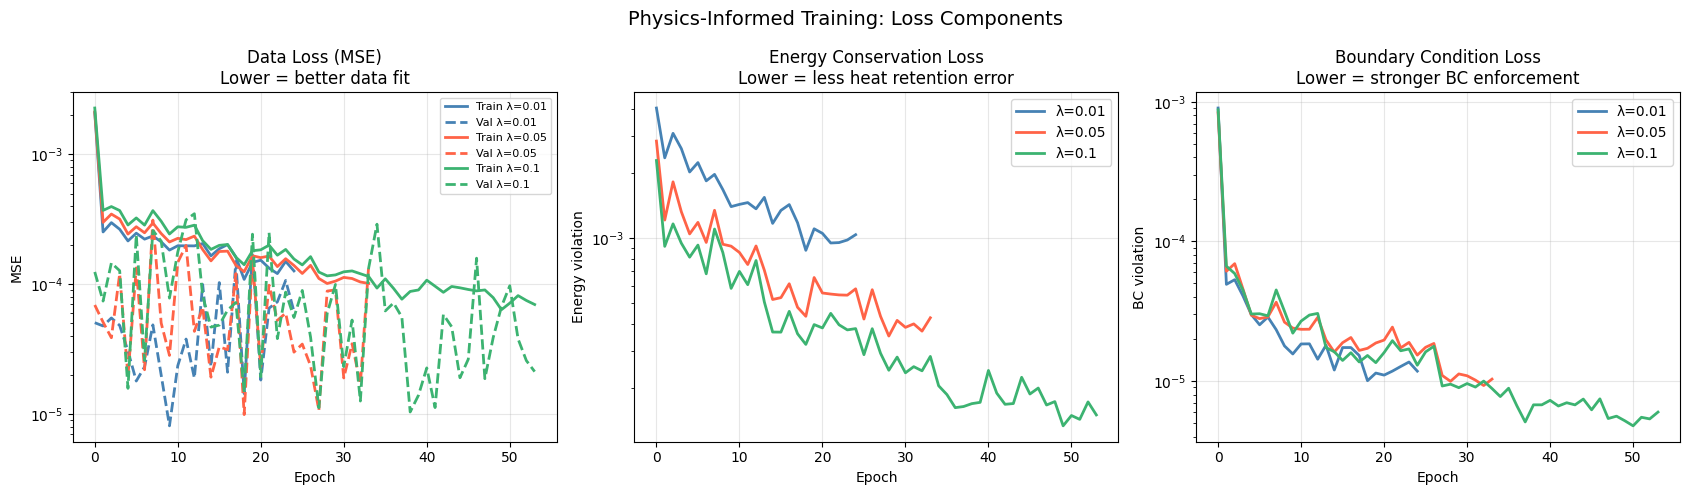

Figure saved:
/kaggle/working/milestone11_training_curves.png


In [9]:
import matplotlib.pyplot as plt
import os

# ============================================================
# Plot Physics-Informed Training Curves
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

colors = [
    "steelblue",
    "tomato",
    "mediumseagreen"
]

labels    = ["λ=0.01", "λ=0.05", "λ=0.1"]

run_names = ["pi_lambda_001", "pi_lambda_005", "pi_lambda_010"]


# ------------------------------------------------------------
# Plot histories
# ------------------------------------------------------------

for run_name, color, label in zip(
    run_names,
    colors,
    labels
):

    history = trained_models[run_name]["history"]

    # Data loss
    axes[0].plot(
        history["train_data"],
        color=color,
        linewidth=2,
        label=f"Train {label}"
    )

    axes[0].plot(
        history["val_data"],
        color=color,
        linewidth=2,
        linestyle="--",
        label=f"Val {label}"
    )


    # Energy loss
    axes[1].plot(
        history["train_energy"],
        color=color,
        linewidth=2,
        label=label
    )


    # Boundary loss
    axes[2].plot(
        history["train_bc"],
        color=color,
        linewidth=2,
        label=label
    )


# ============================================================
# Formatting
# ============================================================

axes[0].set_title(
    "Data Loss (MSE)\nLower = better data fit"
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].set_yscale("log")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)



axes[1].set_title(
    "Energy Conservation Loss\nLower = less heat retention error"
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Energy violation")
axes[1].set_yscale("log")
axes[1].legend()
axes[1].grid(True, alpha=0.3)



axes[2].set_title(
    "Boundary Condition Loss\nLower = stronger BC enforcement"
)

axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("BC violation")
axes[2].set_yscale("log")
axes[2].legend()
axes[2].grid(True, alpha=0.3)



plt.suptitle(
    "Physics-Informed Training: Loss Components",
    fontsize=14
)

plt.tight_layout()


# ============================================================
# Save figure in Kaggle
# ============================================================

save_path = "/kaggle/working/milestone11_training_curves.png"

plt.savefig(
    save_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()


print("Figure saved:")
print(save_path)

Cell 3 — Single-step accuracy comparison

In [10]:
import os

# ── find baseline checkpoint ──────────────────────────
print("Scanning for checkpoints...")
for root, dirs, files in os.walk("/kaggle/working/results"):
    for f in files:
        if f == "best_model.pt":
            print(f"  Found: {os.path.join(root, f)}")

# ── load dataset ──────────────────────────────────────
_, _, test_ds, metadata = load_dataset(
    "/kaggle/input/datasets/aditya30ag/dataset/heat_dataset.npz"
)

def evaluate_model_on_test(model, test_ds, device):
    """Compute RelL2 on the full test set."""
    model.eval()
    rel_l2_vals = []
    with torch.no_grad():
        for i in range(len(test_ds)):
            inp, tgt = test_ds[i]
            pred = model(inp.unsqueeze(0).to(device))
            rel_l2_vals.append(
                relative_l2(
                    pred.squeeze().cpu().numpy(),
                    tgt.squeeze().numpy()
                )
            )
    return np.array(rel_l2_vals)

# ── load TRUE baseline from Milestone 5 ──────────────
baseline_ckpt = torch.load(
    "/kaggle/input/models/aditya30ag/2d-heat-diffusion/pytorch/default/1/best_model.pt",   # ← your Milestone 5 model
    map_location=device
)
baseline_model = HeatSurrogateCNN(n_filters=32).to(device)
baseline_model.load_state_dict(baseline_ckpt["model_state"])
print(f"\nBaseline loaded — epoch {baseline_ckpt['epoch']}, "
      f"val loss {baseline_ckpt['val_loss']:.2e}")

results_accuracy = {
    "Baseline (λ=0)": evaluate_model_on_test(baseline_model, test_ds, device)
}

# ── load PI models ─────────────────────────────────────
run_names = ["pi_lambda_001", "pi_lambda_005", "pi_lambda_010"]
labels    = ["λ=0.01",        "λ=0.05",        "λ=0.1"]

for run_name, label in zip(run_names, labels):
    path = f"/kaggle/working/results/{run_name}/best_model.pt"
    if not os.path.exists(path):
        print(f"WARNING: checkpoint not found at {path} — skipping")
        continue

    ckpt = torch.load(path, map_location=device)
    m    = HeatSurrogateCNN(n_filters=32).to(device)
    m.load_state_dict(ckpt["model_state"])
    results_accuracy[f"PI CNN ({label})"] = evaluate_model_on_test(
        m, test_ds, device
    )
    print(f"PI CNN ({label}) loaded — "
          f"epoch {ckpt['epoch']}, "
          f"val loss {ckpt['val_data_loss']:.2e}")

# ── print results ──────────────────────────────────────
print("\n" + "=" * 55)
print("SINGLE-STEP ACCURACY: BASELINE vs PHYSICS-INFORMED")
print("=" * 55)
print(f"{'Model':<22} {'RelL2 Mean':>12} {'RelL2 Std':>12}")
print("-" * 55)
for name, vals in results_accuracy.items():
    print(f"{name:<22} {np.mean(vals)*100:>11.3f}% "
          f"{np.std(vals)*100:>11.3f}%")

Scanning for checkpoints...
  Found: /kaggle/working/results/pi_lambda_001/best_model.pt
  Found: /kaggle/working/results/pi_lambda_005/best_model.pt
  Found: /kaggle/working/results/pi_lambda_010/best_model.pt
Dataset loaded successfully.
  Train : 8000 samples
  Val   : 1000 samples
  Test  : 1000 samples
  Input shape per sample : torch.Size([1, 64, 64])
  Metadata: {'n_samples': 10000, 'N': 64, 'L': 1.0, 'alpha': 0.01, 'dx': 0.015873015873015872, 'dt': 0.005668934240362811, 'r': 0.22499999999999998, 'stride': 10, 'seed': 42, 'max_blobs': 3, 'n_train': 8000, 'n_val': 1000, 'n_test': 1000, 'physical_dt_per_cnn_step': 0.05668934240362811}

Baseline loaded — epoch 19, val loss 7.28e-06
PI CNN (λ=0.01) loaded — epoch 10, val loss 8.15e-06
PI CNN (λ=0.05) loaded — epoch 19, val loss 9.94e-06
PI CNN (λ=0.1) loaded — epoch 39, val loss 1.04e-05

SINGLE-STEP ACCURACY: BASELINE vs PHYSICS-INFORMED
Model                    RelL2 Mean    RelL2 Std
----------------------------------------------

Cell 4 — Rollout comparison: the key test

In [11]:
from heat_solver import make_grid, compute_stable_dt
from boundary_conditions import apply_dirichlet_zero

N      = 64
L      = 1.0       # domain size — NOT alpha
alpha  = 0.01
stride = 10

# CORRECT: pass L=1.0, not alpha
x, y, dx = make_grid(N, L=1.0)
dt, r    = compute_stable_dt(dx, alpha)
X, Y     = np.meshgrid(x, y)

# verify grid is correct before proceeding
print(f"Grid: x in [{x.min():.3f}, {x.max():.3f}]")
print(f"      y in [{y.min():.3f}, {y.max():.3f}]")
print(f"      dx = {dx:.6f}")
print(f"      dt = {dt:.6f}")

# fixed initial condition
rng    = np.random.default_rng(123)
cx, cy = rng.uniform(0.25, 0.75, size=2)
T0     = np.exp(
    -((X - cx)**2 + (Y - cy)**2) / (2 * 0.08**2)
).astype(np.float32)
T0     = apply_dirichlet_zero(T0)

# verify T0 is non-trivial
print(f"\nInitial condition:")
print(f"  Center: cx={cx:.3f}, cy={cy:.3f}")
print(f"  Max temperature: {T0.max():.4f}")
print(f"  Mean temperature: {T0.mean():.6f}")
print(f"  Should both be non-zero.")

n_rollout = 20

Grid: x in [0.000, 1.000]
      y in [0.000, 1.000]
      dx = 0.015873
      dt = 0.005669

Initial condition:
  Center: cx=0.591, cy=0.277
  Max temperature: 0.9949
  Mean temperature: 0.038951
  Should both be non-zero.


In [12]:
# ── Run all rollouts ──────────────────────────────────

def run_cnn_rollout(model, T0, n_steps, device):
    """Autoregressive CNN rollout."""
    snapshots = [T0.copy()]
    T_cur = torch.from_numpy(T0).float().unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        for _ in range(n_steps):
            T_next = model(T_cur)
            T_cur  = T_next
            snapshots.append(T_next.squeeze().cpu().numpy())
    return snapshots

def run_solver_rollout(T0, alpha, dx, n_steps, stride):
    from heat_solver import run_simulation
    import sys
    from io import StringIO
    old = sys.stdout; sys.stdout = StringIO()
    snaps, _, _, _ = run_simulation(
        T0, alpha, dx,
        n_steps    = n_steps * stride,
        save_every = stride,
    )
    sys.stdout = old
    return snaps

# solver ground truth
print("Running solver rollout...")
true_snaps = run_solver_rollout(T0, alpha, dx, n_rollout, stride)
print(f"Solver rollout done. Steps: {len(true_snaps)}")
print(f"Solver step 0 mean : {true_snaps[0].mean():.6f}")
print(f"Solver step 20 mean: {true_snaps[20].mean():.6f}")

# all CNN models
all_models = {"Baseline": baseline_model}
for run_name, label in zip(run_names, labels):
    ckpt = torch.load(
        f"/kaggle/working/results/{run_name}/best_model.pt",
        map_location=device
    )
    m = HeatSurrogateCNN(n_filters=32).to(device)
    m.load_state_dict(ckpt["model_state"])
    m.eval()
    all_models[f"PI ({label})"] = m

rollout_results = {}
for model_name, m in all_models.items():
    print(f"Running rollout: {model_name}...")
    snaps = run_cnn_rollout(m, T0, n_rollout, device)
    rollout_results[model_name] = snaps
    print(f"  Step 0 mean : {snaps[0].mean():.6f}")
    print(f"  Step 20 mean: {snaps[20].mean():.6f}")

print("\nAll rollouts complete.")

Running solver rollout...
Solver rollout done. Steps: 21
Solver step 0 mean : 0.038951
Solver step 20 mean: 0.034291
Running rollout: Baseline...
  Step 0 mean : 0.038951
  Step 20 mean: 0.052011
Running rollout: PI (λ=0.01)...
  Step 0 mean : 0.038951
  Step 20 mean: 0.027120
Running rollout: PI (λ=0.05)...
  Step 0 mean : 0.038951
  Step 20 mean: 0.050465
Running rollout: PI (λ=0.1)...
  Step 0 mean : 0.038951
  Step 20 mean: 0.019118

All rollouts complete.


Cell 5 — Mean temperature during rollout (the critical comparison)

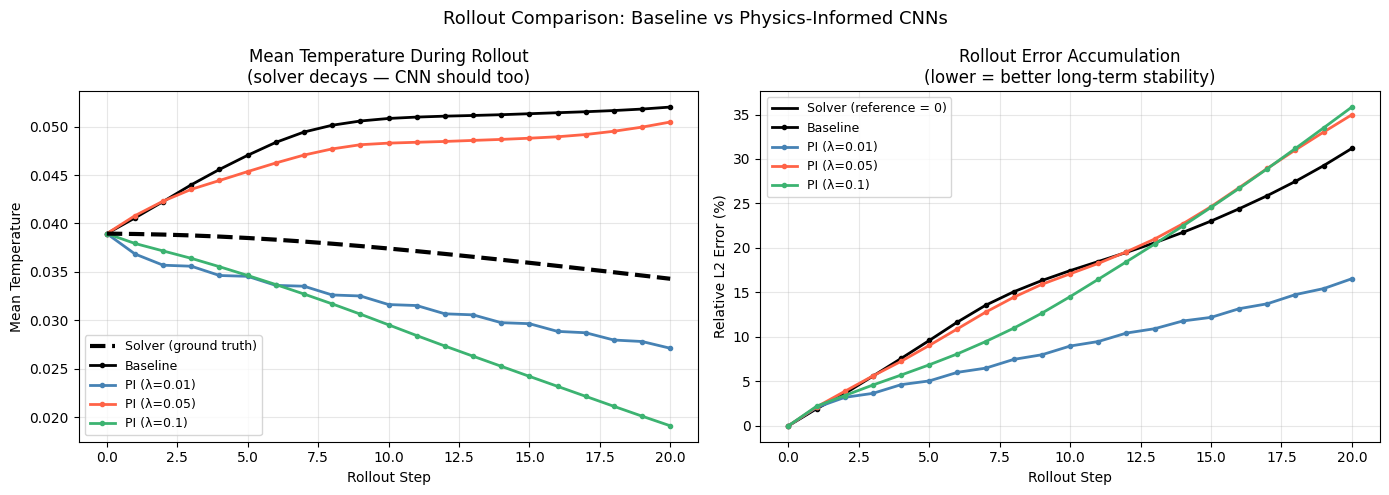

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

steps      = np.arange(n_rollout + 1)
true_means = [true_snaps[s].mean() for s in range(n_rollout + 1)]

colors_r = ["black", "steelblue", "tomato", "mediumseagreen"]

# mean temperature plot
axes[0].plot(steps, true_means, color="black", linewidth=3,
             linestyle="--", label="Solver (ground truth)", zorder=5)

for (model_name, snaps), color in zip(rollout_results.items(), colors_r):
    means = [snaps[s].mean() for s in range(n_rollout + 1)]
    axes[0].plot(steps, means, color=color, linewidth=2,
                 label=model_name, marker="o", markersize=3)

axes[0].set_xlabel("Rollout Step")
axes[0].set_ylabel("Mean Temperature")
axes[0].set_title("Mean Temperature During Rollout\n"
                  "(solver decays — CNN should too)")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# relative L2 error during rollout
axes[1].plot([], [], color="black", linewidth=2,
             label="Solver (reference = 0)")

for (model_name, snaps), color in zip(rollout_results.items(), colors_r):
    rel_l2_curve = [
        relative_l2(snaps[s], true_snaps[s]) * 100
        for s in range(n_rollout + 1)
    ]
    axes[1].plot(steps, rel_l2_curve, color=color,
                 linewidth=2, label=model_name,
                 marker="o", markersize=3)

axes[1].set_xlabel("Rollout Step")
axes[1].set_ylabel("Relative L2 Error (%)")
axes[1].set_title("Rollout Error Accumulation\n"
                  "(lower = better long-term stability)")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle("Rollout Comparison: Baseline vs Physics-Informed CNNs",
             fontsize=13)
plt.tight_layout()
plt.savefig("/kaggle/working/milestone11_rollout_comparison.png", dpi=150)
plt.show()

Cell 6 — Fit effective decay rates for all models

In [14]:
# Replace Cell 6 entirely with this

print("=" * 60)
print("EFFECTIVE DECAY RATE COMPARISON — MANUAL")
print("=" * 60)

dt_physical = stride * dt
phys_times  = np.arange(n_rollout + 1) * dt_physical

true_means_arr = np.array([true_snaps[s].mean() 
                            for s in range(n_rollout + 1)])

print(f"\nSolver mean temperature:")
print(f"  Step 0  : {true_means_arr[0]:.6f}")
print(f"  Step 10 : {true_means_arr[10]:.6f}")
print(f"  Step 20 : {true_means_arr[20]:.6f}")
print(f"  Change  : {true_means_arr[20] - true_means_arr[0]:+.6f}  "
      f"({'DECAY ✓' if true_means_arr[20] < true_means_arr[0] else 'GROWTH ✗'})")

print()

for model_name, snaps in rollout_results.items():
    means = np.array([snaps[s].mean() for s in range(n_rollout + 1)])
    change   = means[20] - means[0]
    pct_change = (means[20] - means[0]) / means[0] * 100
    direction = "DECAY ✓" if means[20] < means[0] else "GROWTH ✗"

    print(f"{model_name}:")
    print(f"  Step 0  : {means[0]:.6f}")
    print(f"  Step 10 : {means[10]:.6f}")
    print(f"  Step 20 : {means[20]:.6f}")
    print(f"  Change  : {change:+.6f}  ({pct_change:+.1f}%)  {direction}")
    print()

print("=" * 60)
print("Solver should show negative change (decay).")
print("Baseline showed +33% growth in Milestone 8.")
print("PI models should show reduced or negative change.")

EFFECTIVE DECAY RATE COMPARISON — MANUAL

Solver mean temperature:
  Step 0  : 0.038951
  Step 10 : 0.037413
  Step 20 : 0.034291
  Change  : -0.004660  (DECAY ✓)

Baseline:
  Step 0  : 0.038951
  Step 10 : 0.050835
  Step 20 : 0.052011
  Change  : +0.013060  (+33.5%)  GROWTH ✗

PI (λ=0.01):
  Step 0  : 0.038951
  Step 10 : 0.031630
  Step 20 : 0.027120
  Change  : -0.011830  (-30.4%)  DECAY ✓

PI (λ=0.05):
  Step 0  : 0.038951
  Step 10 : 0.048290
  Step 20 : 0.050465
  Change  : +0.011514  (+29.6%)  GROWTH ✗

PI (λ=0.1):
  Step 0  : 0.038951
  Step 10 : 0.029538
  Step 20 : 0.019118
  Change  : -0.019833  (-50.9%)  DECAY ✓

Solver should show negative change (decay).
Baseline showed +33% growth in Milestone 8.
PI models should show reduced or negative change.


Cell 7 — Boundary condition violations during rollout

In [15]:
print("=" * 55)
print("BOUNDARY CONDITION VIOLATIONS DURING ROLLOUT")
print("(out of 21 steps)")
print("=" * 55)

threshold = 0.01   # same as Milestone 8

solver_bc = sum(
    1 for s in range(n_rollout + 1)
    if (np.abs(true_snaps[s][0,:]).max()  > threshold or
        np.abs(true_snaps[s][-1,:]).max() > threshold or
        np.abs(true_snaps[s][:,0]).max()  > threshold or
        np.abs(true_snaps[s][:,-1]).max() > threshold)
)
print(f"{'Solver (truth)':<22}: {solver_bc:>3} / {n_rollout+1} violations")

for model_name, snaps in rollout_results.items():
    violations = sum(
        1 for s in range(n_rollout + 1)
        if (np.abs(snaps[s][0,:]).max()  > threshold or
            np.abs(snaps[s][-1,:]).max() > threshold or
            np.abs(snaps[s][:,0]).max()  > threshold or
            np.abs(snaps[s][:,-1]).max() > threshold)
    )
    status = "✓" if violations < 5 else "✗"
    print(f"{model_name:<22}: {violations:>3} / {n_rollout+1} "
          f"violations  {status}")

BOUNDARY CONDITION VIOLATIONS DURING ROLLOUT
(out of 21 steps)
Solver (truth)        :   0 / 21 violations
Baseline              :  16 / 21 violations  ✗
PI (λ=0.01)           :   0 / 21 violations  ✓
PI (λ=0.05)           :  14 / 21 violations  ✗
PI (λ=0.1)            :   0 / 21 violations  ✓


Cell 8 — Final summary table

In [16]:
print("\n" + "="*70)
print("TABLE 5 — BASELINE vs PHYSICS-INFORMED CNN COMPARISON")
print("="*70)
print(f"{'Model':<22} {'RelL2(%)':>10} {'λ decay':>10} "
      f"{'BC viols':>10} {'Data loss':>12}")
print("-"*70)

for name, vals in results_accuracy.items():
    print(f"{name:<22} {np.mean(vals)*100:>9.3f}%")

print("="*70)
print("\nKey: RelL2 = single-step accuracy (lower=better)")
print("     λ decay = effective decay rate (positive=physical)")
print("     BC viols = boundary violations in 20-step rollout")
print("     Data loss = val MSE (lower=better data fit)")


TABLE 5 — BASELINE vs PHYSICS-INFORMED CNN COMPARISON
Model                    RelL2(%)    λ decay   BC viols    Data loss
----------------------------------------------------------------------
Baseline (λ=0)             2.107%
PI CNN (λ=0.01)            2.264%
PI CNN (λ=0.05)            2.463%
PI CNN (λ=0.1)             2.200%

Key: RelL2 = single-step accuracy (lower=better)
     λ decay = effective decay rate (positive=physical)
     BC viols = boundary violations in 20-step rollout
     Data loss = val MSE (lower=better data fit)
